# Line Plots & the Related Plot Family

A practical tutorial for visualising **time series and continuous data** using `matplotlib` and `seaborn`.

**What you'll cover:**
1. The basic line plot (`plt.plot`)
2. Seaborn `lineplot` — the statistical line plot
3. Multiple lines, hue, style & size encodings
4. Confidence intervals & aggregation
5. `relplot` — the figure-level interface (faceting)
6. Related family members: `scatterplot`, `area`, `step`, `fill_between`
7. Time series specifics (dates, rolling means)
8. Styling & best practices

> **Tip:** Use a **line plot** when the x-axis has a natural order (time, sequence). Use a **scatter plot** when it does not.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")   # clean default styling
%matplotlib inline

print("seaborn", sns.__version__)
print("matplotlib", plt.matplotlib.__version__)

seaborn 0.13.2
matplotlib 3.10.0


In [2]:
# Build a small synthetic time series dataset to use throughout
rng = np.random.default_rng(42)

dates = pd.date_range("2023-01-01", periods=365, freq="D")
trend = np.linspace(100, 160, 365)                 # upward trend (level + trend)
season = 15 * np.sin(np.arange(365) * 2 * np.pi / 30)  # ~monthly seasonality
noise = rng.normal(0, 4, 365)                       # random noise

df = pd.DataFrame({
    "date": dates,
    "sales": trend + season + noise,
    "region": rng.choice(["North", "South"], size=365),
})
df["month"] = df["date"].dt.month
df.head()

,date,sales,region,month
0,2023-01-01,101.218868,North,1
1,2023-01-02,99.123574,South,1
2,2023-01-03,109.432525,North,1
3,2023-01-04,113.073543,South,1
4,2023-01-05,104.002372,South,1


## 1. The Basic Line Plot — `plt.plot`

The most fundamental line plot. You pass `x` and `y` arrays; matplotlib connects the points in order.

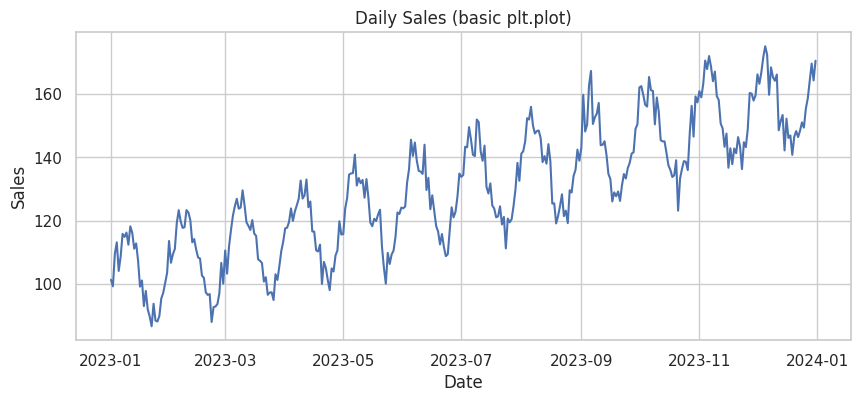

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["sales"])
plt.title("Daily Sales (basic plt.plot)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

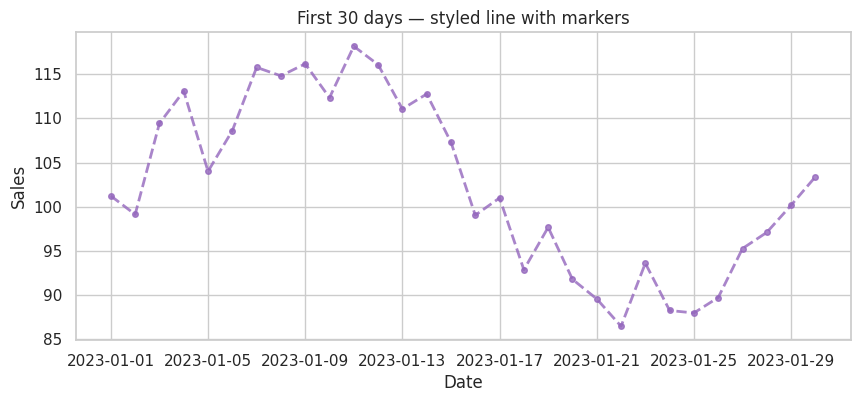

In [4]:
# Common style arguments: color, linewidth (lw), linestyle (ls), marker, alpha
plt.figure(figsize=(10, 4))
plt.plot(df["date"][:30], df["sales"][:30],
         color="tab:purple", lw=2, ls="--", marker="o", markersize=4, alpha=0.8)
plt.title("First 30 days — styled line with markers")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.show()

### Pandas convenience plotting
A DataFrame/Series has a built-in `.plot()` that wraps matplotlib — handy for quick looks.

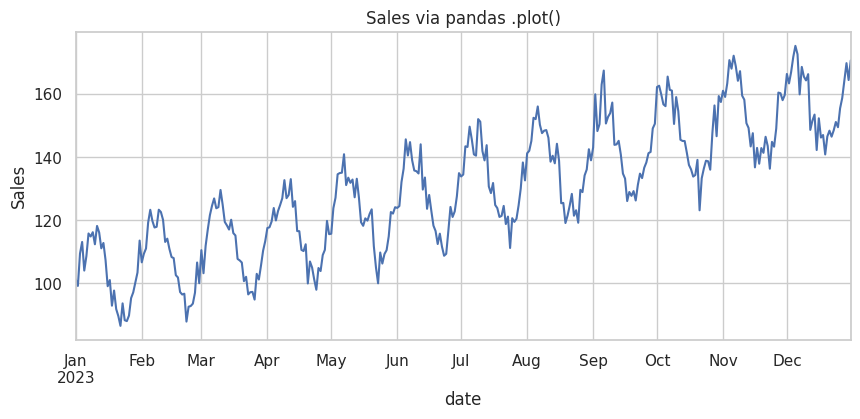

In [5]:
df.set_index("date")["sales"].plot(figsize=(10, 4), title="Sales via pandas .plot()")
plt.ylabel("Sales")
plt.show()

## 2. Seaborn `lineplot` — the Statistical Line Plot

`sns.lineplot` is *axes-level*. Its superpower: when there are **multiple y-values per x**, it automatically **aggregates (mean)** and draws a **confidence interval** band.

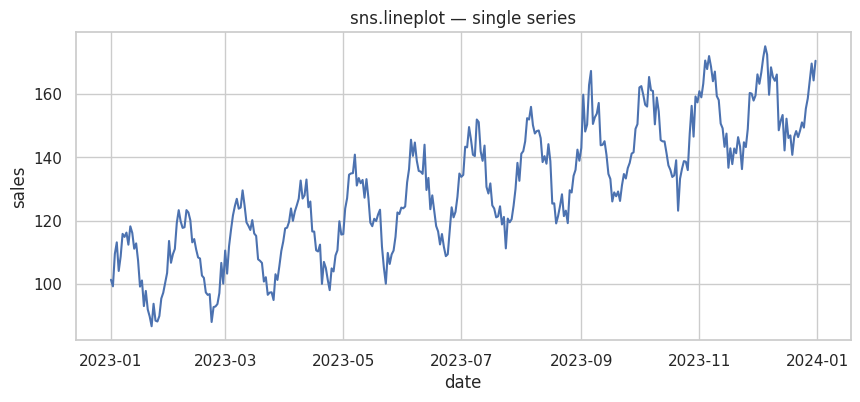

In [6]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x="date", y="sales")
plt.title("sns.lineplot — single series")
plt.show()

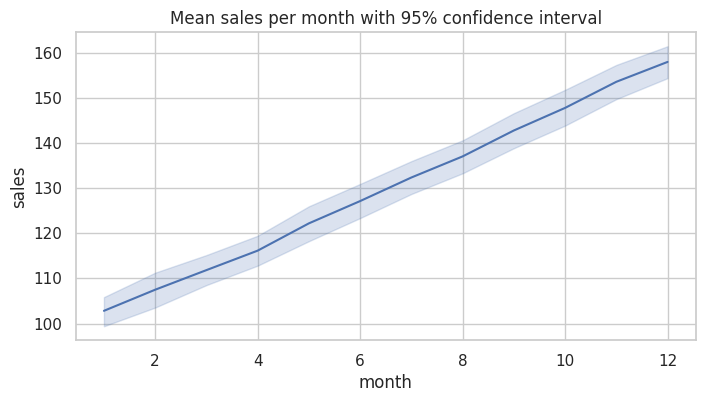

In [7]:
# Aggregation in action: plot sales by MONTH.
# Many days share the same month -> seaborn shows the mean line + 95% CI band.
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x="month", y="sales")
plt.title("Mean sales per month with 95% confidence interval")
plt.show()

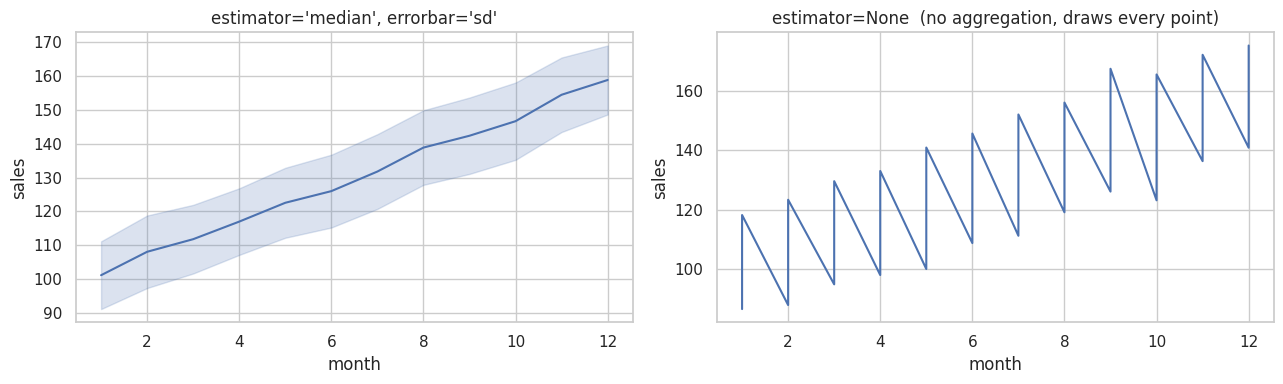

In [8]:
# Control the aggregation and the error band
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=df, x="month", y="sales", estimator="median", errorbar="sd", ax=axes[0])
axes[0].set_title("estimator='median', errorbar='sd'")

sns.lineplot(data=df, x="month", y="sales", estimator=None, ax=axes[1])
axes[1].set_title("estimator=None  (no aggregation, draws every point)")

plt.tight_layout(); plt.show()

## 3. Multiple Lines — `hue`, `style`, `size`

These *semantic mappings* split one column into several visually-distinguished lines:

| Argument | Effect |
|----------|--------|
| `hue`   | different **colour** per category |
| `style` | different **dash pattern / markers** per category |
| `size`  | different **line width** per category |

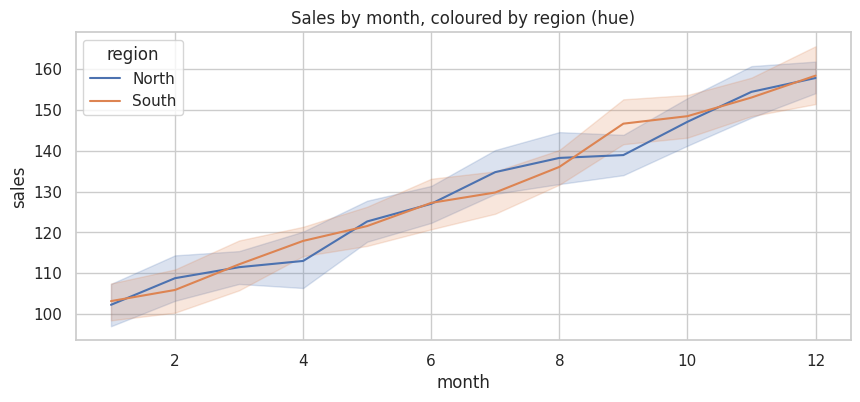

In [9]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x="month", y="sales", hue="region")
plt.title("Sales by month, coloured by region (hue)")
plt.show()

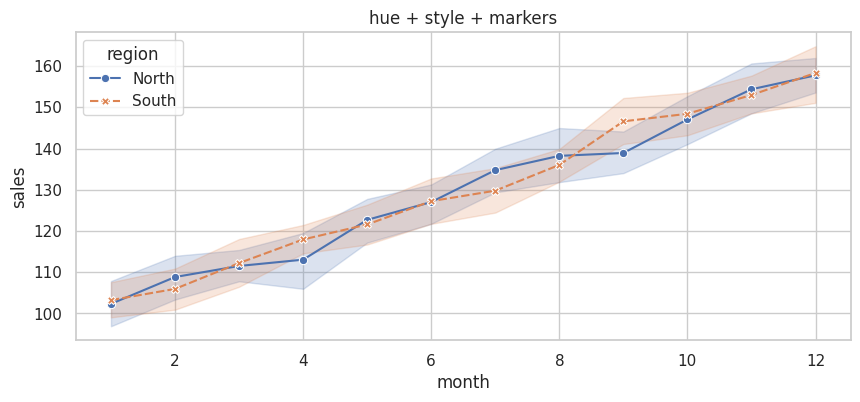

In [10]:
# Combine hue + style + markers for print-friendly distinction
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x="month", y="sales",
             hue="region", style="region", markers=True, dashes=True)
plt.title("hue + style + markers")
plt.show()

## 4. `relplot` — the Figure-Level Interface (Faceting)

`sns.relplot` is the **figure-level** relational plotter. With `kind="line"` it calls `lineplot` under the hood, but adds **faceting** via `row` / `col` — splitting data into a grid of subplots.

- `kind="line"` → line plots
- `kind="scatter"` (default) → scatter plots

> Axes-level (`lineplot`) draws on one Axes you control. Figure-level (`relplot`) manages the whole figure and returns a `FacetGrid`.

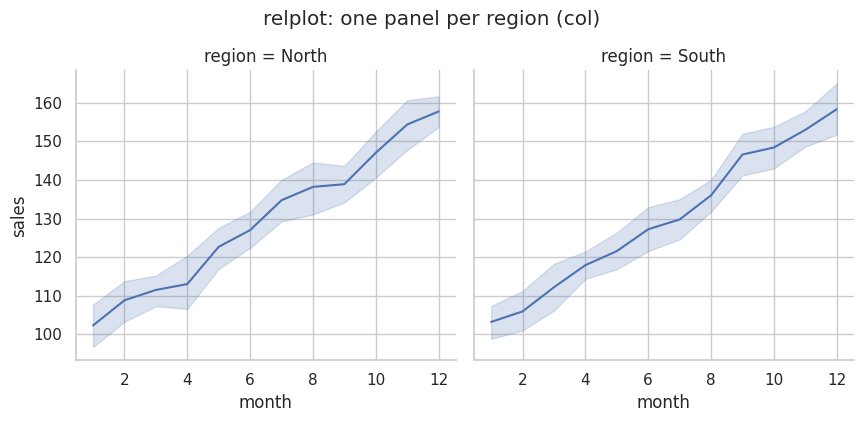

In [11]:
sns.relplot(data=df, x="month", y="sales", kind="line",
            col="region", height=4, aspect=1.1)
plt.suptitle("relplot: one panel per region (col)", y=1.05)
plt.show()

In [ ]:
# hue inside each facet
sns.relplot(data=df, x="month", y="sales", kind="line",
            hue="region", col="region", height=4)
plt.show()

## 5. The Related Plot Family

Line plots belong to a broader family of plots for showing how a quantity changes. Here are the close relatives.

### 5a. Scatter plot — same family, no connecting line
Use when points are independent observations rather than an ordered sequence.

In [ ]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df, x="date", y="sales", hue="region", alpha=0.6)
plt.title("scatterplot — the non-connected cousin")
plt.show()

### 5b. Area plot — line + filled region under it
Emphasises magnitude / cumulative volume.

In [ ]:
monthly = df.groupby("month")["sales"].mean()

plt.figure(figsize=(10, 4))
plt.fill_between(monthly.index, monthly.values, alpha=0.3, color="tab:blue")
plt.plot(monthly.index, monthly.values, color="tab:blue", lw=2)
plt.title("Area plot via fill_between")
plt.xlabel("Month"); plt.ylabel("Mean sales")
plt.show()

### 5c. Step plot — values constant between samples
Ideal for discrete state changes (inventory level, price tiers).

In [ ]:
plt.figure(figsize=(10, 4))
plt.step(monthly.index, monthly.values, where="mid", marker="o")
plt.title("Step plot (plt.step)")
plt.xlabel("Month"); plt.ylabel("Mean sales")
plt.show()

### 5d. Confidence band manually — `fill_between` around a mean
Reproduces what `lineplot` does automatically, but with full control.

In [ ]:
g = df.groupby("month")["sales"]
mean, std = g.mean(), g.std()

plt.figure(figsize=(10, 4))
plt.plot(mean.index, mean.values, label="mean", color="tab:red")
plt.fill_between(mean.index, mean - std, mean + std, alpha=0.2, color="tab:red", label="\u00b11 std")
plt.legend(); plt.title("Manual mean \u00b1 std band")
plt.xlabel("Month"); plt.ylabel("Sales")
plt.show()

## 6. Time Series Specifics

Two things that come up constantly with dated line plots: **rolling means** (to expose trend through noise) and **readable date axes**.

In [ ]:
import matplotlib.dates as mdates

ts = df.set_index("date")["sales"]
roll = ts.rolling(window=14).mean()   # 14-day moving average

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts.index, ts.values, color="lightgray", lw=1, label="daily")
ax.plot(roll.index, roll.values, color="tab:blue", lw=2, label="14-day rolling mean")

# Make the date axis readable
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_title("Raw series vs. rolling mean (trend extraction)")
ax.set_ylabel("Sales"); ax.legend()
plt.show()

## 7. Styling Cheatsheet & Best Practices

**Key `plt.plot` arguments**
- `color` / `c` — line colour (`"tab:blue"`, `"#33aa55"`)
- `linewidth` / `lw` — thickness
- `linestyle` / `ls` — `"-"`, `"--"`, `"-."`, `":"`
- `marker` — `"o"`, `"s"`, `"^"`, `"."`
- `alpha` — transparency (0–1)
- `label` — for the legend

**Axes vs. Figure level (seaborn)**
- `lineplot`, `scatterplot` → *axes-level*: draw onto an existing `ax`, easy to combine into subplots.
- `relplot` → *figure-level*: owns the figure, supports `row`/`col` faceting, returns a `FacetGrid`.

**When to use which**
- Ordered x (time/sequence) → **line plot**
- Unordered observations → **scatter plot**
- Many y per x → **lineplot** (auto mean + CI)
- Need small multiples → **relplot** with `col`/`row`
- Emphasise magnitude → **area** (`fill_between`)
- Discrete step changes → **step**

**Good habits**
- Always label axes and add a title.
- Use `figsize` wide for time series (e.g. `(10, 4)`).
- Add a legend when there's more than one line.
- Use `alpha` when lines/points overlap heavily.

### Mini-exercise
Try these on `df`:
1. Plot a **30-day rolling mean** instead of 14-day. How does the trend look?
2. Use `relplot` with `kind="line"`, `hue="region"`, and `col="region"` on the **daily** data.
3. Recreate the month CI band using `errorbar=("ci", 90)` and compare to the default 95%.

In [ ]:
# Your turn:
